In [1]:
import gzip
import json


In [2]:

path = "reviews_Toys_and_Games_5.json.gz"

with gzip.open(path, "rt", encoding="utf-8") as f:
    for i in range(5):
        line = f.readline()
        data = eval(line)
        print(f"\n--- Review {i+1} ---")
        print(data)


--- Review 1 ---
{'reviewerID': 'A1VXOAVRGKGEAK', 'asin': '0439893577', 'reviewerName': 'Angie', 'helpful': [0, 0], 'reviewText': 'I like the item pricing. My granddaughter wanted to mark on it but I wanted it just for the letters.', 'overall': 5.0, 'summary': 'Magnetic board', 'unixReviewTime': 1390953600, 'reviewTime': '01 29, 2014'}

--- Review 2 ---
{'reviewerID': 'A8R62G708TSCM', 'asin': '0439893577', 'reviewerName': 'Candace', 'helpful': [1, 1], 'reviewText': 'Love the magnet easel... great for moving to different areas... Wish it had some sort of non skid pad on bottom though...', 'overall': 4.0, 'summary': 'it works pretty good for moving to different areas', 'unixReviewTime': 1395964800, 'reviewTime': '03 28, 2014'}

--- Review 3 ---
{'reviewerID': 'A21KH420DK0ICA', 'asin': '0439893577', 'reviewerName': 'capemaychristy', 'helpful': [1, 1], 'reviewText': "Both sides are magnetic.  A real plus when you're entertaining more than one child.  The four-year old can find the letters

In [3]:
count = 0

with gzip.open(path, "rt", encoding="utf-8") as f:
    for line in f:
        count += 1

print("Total reviews:", count)

Total reviews: 167597


In [4]:
users = set()
items = set()

with gzip.open(path, "rt", encoding="utf-8") as f:
    for line in f:
        d = eval(line)

        users.add(d["reviewerID"])
        items.add(d["asin"])

print("Users :", len(users))
print("Items :", len(items))
print("Interactions :", count)

Users : 19412
Items : 11924
Interactions : 167597


In [5]:
data

{'reviewerID': 'ACCH8EOML6FN5',
 'asin': '0439893577',
 'reviewerName': 'DoyZ',
 'helpful': [1, 1],
 'reviewText': 'I have a stainless steel refrigerator therefore there are not much space for my son to play with his magnet. Brought this for him to put his magnet on. He enjoys sticking his magnet on it. Great to have so he can play with his alphabet magnets.',
 'overall': 4.0,
 'summary': 'Great to have so he can play with his alphabet ...',
 'unixReviewTime': 1399248000,
 'reviewTime': '05 5, 2014'}

In [6]:
import gzip

path = r"C:\Users\Ehsan\Desktop\New folder (3)\reviews_Toys_and_Games_5.json.gz"

users = set()
items = set()
count = 0

with gzip.open(path, "rt", encoding="utf-8") as f:
    for line in f:
        d = eval(line)

        users.add(d["reviewerID"])
        items.add(d["asin"])
        count += 1

print("Users        :", len(users))
print("Items        :", len(items))
print("Interactions :", count)

Users        : 19412
Items        : 11924
Interactions : 167597


In [4]:
import pandas as pd

ratings_path = r"C:\Users\Ehsan\Desktop\New folder (3)\reviews_Toys_and_Games_5.json.gz"

# خواندن فایل
df = pd.read_json(ratings_path, lines=True, compression="gzip")

# انتخاب و تغییر نام ستون‌ها
ratings = df[["reviewerID", "asin", "overall", "unixReviewTime"]].copy()
ratings.columns = ["user_id", "item_id", "rating", "timestamp"]

# نمایش نتیجه
print(ratings.shape)
ratings.head()

(167597, 4)


,user_id,item_id,rating,timestamp
0,A1VXOAVRGKGEAK,0439893577,5,1390953600
1,A8R62G708TSCM,0439893577,4,1395964800
2,A21KH420DK0ICA,0439893577,5,1359331200
3,AR29QK6HPFYZ4,0439893577,5,1391817600
4,ACCH8EOML6FN5,0439893577,4,1399248000


In [10]:
import os
import random
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import torch
import faiss

In [29]:
# -*- coding: utf-8 -*-




# ============================================================
# CONFIG
# ============================================================

INPUT_FILE = r"C:\Users\Ehsan\Desktop\New folder (3)\reviews_Toys_and_Games_5.json.gz"
OUTPUT_FILE = r"C:\Users\Ehsan\Desktop\New folder (3)\toys_p11_learning1_faiss.pt"

RANDOM_SEED = 12345

MAX_SEQ_LENGTH = 50
PROP_SLIDING_WINDOW = 0.1
SAMPLE_NUM = 20

# 11 preference tokens مثل کد اصلی
SPECIAL_TOKENS = [
    "[Preference_1]",
    "[Preference_2]",
    "[Preference_3]",
    "[Preference_4]",
    "[Preference_5]",
    "[Preference_6]",
    "[Preference_7]",
    "[Preference_8]",
    "[Preference_9]",
    "[Preference_10]",
    "[Preference_11]",
]


# ============================================================
# SEED
# ============================================================

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# ============================================================
# FREQ VOCAB
# ============================================================

class FreqVocab:

    def __init__(self, user_to_list):

        self.counter = Counter()
        self.user_set = set()

        for user, item_list in user_to_list.items():
            self.counter.update(item_list)
            self.user_set.add(str(user))

        self.user_count = len(self.user_set)
        self.item_count = len(self.counter)

        self.special_tokens = SPECIAL_TOKENS

        # item -> integer ID
        # 0 reserved for padding
        self.token_to_ids = {}

        for token, count in self.counter.most_common():
            self.token_to_ids[token] = len(self.token_to_ids) + 1

        # preference tokens
        for token in self.special_tokens:
            self.token_to_ids[token] = len(self.token_to_ids) + 1

        # integer ID -> token
        self.id_to_tokens = {
            v: k for k, v in self.token_to_ids.items()
        }

        self.vocab_words = list(self.token_to_ids.keys())

    def convert_tokens_to_ids(self, tokens):
        return [self.token_to_ids[token] for token in tokens]

    def convert_ids_to_tokens(self, ids):
        return [self.id_to_tokens[i] for i in ids]

    def get_vocab_words(self):
        return self.vocab_words

    def get_item_count(self):
        return self.item_count

    def get_user_count(self):
        return self.user_count

    def get_items(self):
        return list(self.counter.keys())

    def get_users(self):
        return self.user_set

    def get_special_token_count(self):
        return len(self.special_tokens)

    def get_special_token(self):
        return self.special_tokens

    def get_preference_token(self):
        return self.special_tokens

    def get_preference_token_size(self):
        return len(self.special_tokens)

    def get_vocab_size(self):
        return (
            self.get_item_count()
            + self.get_special_token_count()
            + 1
        )


In [30]:
import json
import gzip
import pandas as pd


def load_raw_data(filename):

    print("\nLoading:", filename)

    rows = []

    # Amazon dataset is gzip-compressed JSON Lines
    with gzip.open(filename, "rt", encoding="utf-8") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            obj = json.loads(line)

            rows.append({
                "user_id": obj["reviewerID"],
                "item_id": obj["asin"],
                "rating": obj["overall"],
                "timestamp": obj["unixReviewTime"]
            })

    df = pd.DataFrame(rows)

    # -----------------------------
    # Types
    # -----------------------------

    df["user_id"] = df["user_id"].astype(str)
    df["item_id"] = df["item_id"].astype(str)

    df["rating"] = pd.to_numeric(
        df["rating"],
        errors="coerce"
    )

    df["timestamp"] = pd.to_numeric(
        df["timestamp"],
        errors="coerce"
    )

    # Remove invalid rows
    df = df.dropna(
        subset=[
            "user_id",
            "item_id",
            "rating",
            "timestamp"
        ]
    )

    # -----------------------------
    # Chronological order
    # -----------------------------

    df = df.sort_values(
        ["user_id", "timestamp"]
    ).reset_index(drop=True)

    print("\nNumber of interactions:", len(df))
    print("Number of users:", df["user_id"].nunique())
    print("Number of items:", df["item_id"].nunique())

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nFirst rows:")
    print(df.head())

    return df

In [31]:
# CONVERT STRING IDS -> INTEGER IDS
# ============================================================

def create_id_mapping(df):

    user_ids = df["user_id"].unique().tolist()
    item_ids = df["item_id"].unique().tolist()

    # 0 = padding
    user_to_idx = {
        user_id: idx + 1
        for idx, user_id in enumerate(user_ids)
    }

    item_to_idx = {
        item_id: idx + 1
        for idx, item_id in enumerate(item_ids)
    }

    idx_to_user = {
        idx: user
        for user, idx in user_to_idx.items()
    }

    idx_to_item = {
        idx: item
        for item, idx in item_to_idx.items()
    }

    df["user_idx"] = df["user_id"].map(user_to_idx)
    df["item_idx"] = df["item_id"].map(item_to_idx)

    return (
        df,
        user_to_idx,
        item_to_idx,
        idx_to_user,
        idx_to_item
    )


# ============================================================
# DATA PARTITION
# ============================================================

def data_partition(df):

    """
    Equivalent to original data_partition()

    Original:
        <3 interactions:
            train = all

        >=3:
            train = seq[:-2]
            valid = seq[-2]
            test = seq[-1]

    """

    User = defaultdict(list)

    # هر interaction کامل نگه داشته می‌شود
    for row in df.itertuples(index=False):

        interaction = {
            "item_idx": int(row.item_idx),
            "item_id": row.item_id,
            "rating": float(row.rating),
            "timestamp": int(row.timestamp)
        }

        User[int(row.user_idx)].append(interaction)

    user_train = {}
    user_valid = {}
    user_test = {}

    for user in User:

        seq = User[user]

        if len(seq) < 3:

            user_train[user] = seq
            user_valid[user] = []
            user_test[user] = []

        else:

            user_train[user] = seq[:-2]

            user_valid[user] = [
                seq[-2]
            ]

            user_test[user] = [
                seq[-1]
            ]

    return (
        user_train,
        user_valid,
        user_test
    )


# ============================================================
# CONVERT TO TOKEN FORMAT
# ============================================================

def build_token_data(
    user_train,
    user_valid,
    user_test
):

    # --------------------------------------------------------
    # IMPORTANT:
    #
    # original code:
    #
    # for u in user_train:
    #     user_train[u].extend(user_valid[u])
    #
    # --------------------------------------------------------

    for user in user_train:

        if user in user_valid:

            user_train[user].extend(
                user_valid[user]
            )

    # --------------------------------------------------------
    # user_train_data
    # --------------------------------------------------------

    user_train_data = {}

    for user, interactions in user_train.items():

        if len(interactions) == 0:
            continue

        user_train_data[
            "user_" + str(user)
        ] = [

            "item_" + str(x["item_idx"])

            for x in interactions

        ]

    # --------------------------------------------------------
    # test data = train + test
    # --------------------------------------------------------

    user_test_data = {}

    for user in user_train:

        if (
            len(user_train[user]) > 0
            and len(user_test[user]) > 0
        ):

            all_interactions = (
                user_train[user]
                + user_test[user]
            )

            user_test_data[
                "user_" + str(user)
            ] = [

                "item_" + str(x["item_idx"])

                for x in all_interactions

            ]

    return (
        user_train_data,
        user_test_data,
        user_train,
        user_test
    )


# ============================================================
# CREATE TRAINING INSTANCES
# ============================================================

class TrainingInstance:

    def __init__(
        self,
        info,
        tokens,
        masked_lm_labels,
        sid,
        ratings,
        timestamps
    ):

        self.info = info

        self.tokens = tokens

        self.masked_lm_labels = masked_lm_labels

        self.sid = sid

        self.ratings = ratings

        self.timestamps = timestamps


In [32]:
# ============================================================
# MASK LAST
# ============================================================

def mask_last(
    s_data,
    max_seq_length
):

    user = s_data[0]
    sid = s_data[1]

    # --------------------------------------------------------
    # s_data structure:
    #
    # [user, sid,
    #  item1, item2, item3, ...]
    # --------------------------------------------------------

    tokens = s_data[2:]

    assert (
        len(tokens) >= 2
        and len(tokens)
        <= max_seq_length + len(SPECIAL_TOKENS)
    )

    output_tokens = tokens[:-1]

    label = [tokens[-1]]

    instance = TrainingInstance(

        info=[
            int(user.split("_")[1])
        ],

        tokens=output_tokens,

        masked_lm_labels=label,

        sid=sid,

        ratings=s_data[
            2 + len(SPECIAL_TOKENS) * 0:
        ],

        timestamps=[]
    )

    return instance


# ============================================================
# TRAIN INSTANCES WITH METADATA
# ============================================================

def create_instances(
    user_train_data,
    user_train_metadata,
    max_seq_length,
    prop_sliding_window,
    vocab
):

    all_documents = {}

    # --------------------------------------------------------
    # Create sliding windows
    # --------------------------------------------------------

    sliding_step = int(
        prop_sliding_window * max_seq_length
    )

    if sliding_step <= 0:
        sliding_step = max_seq_length

    for user, item_seq in user_train_data.items():

        if len(item_seq) == 0:
            continue

        metadata = user_train_metadata[user]

        # ----------------------------------------------------
        # <= 50
        # ----------------------------------------------------

        if len(item_seq) <= max_seq_length:

            tokens = (
                vocab.get_preference_token()
                + item_seq
            )

            all_documents[user] = [
                (
                    tokens,
                    metadata
                )
            ]

        # ----------------------------------------------------
        # > 50
        # ----------------------------------------------------

        else:

            beg_idx = list(
                range(
                    len(item_seq) - max_seq_length,
                    0,
                    -sliding_step
                )
            )

            beg_idx.append(0)

            beg_idx = beg_idx[::-1]

            all_documents[user] = []

            for i in beg_idx:

                tokens = (
                    vocab.get_preference_token()
                    + item_seq[
                        i:i + max_seq_length
                    ]
                )

                meta = metadata[
                    i:i + max_seq_length
                ]

                all_documents[user].append(
                    (
                        tokens,
                        meta
                    )
                )

    # ========================================================
    # PREFIX DATA AUGMENTATION
    # ========================================================

    new_slid_data = []

    pre_num = vocab.get_preference_token_size()

    sid = 0

    for user in all_documents:

        for seq, metadata in all_documents[user]:

            if len(seq) == pre_num:
                continue

            # ------------------------------------------------
            # original:
            #
            # for i in range(pre_num+1, len(seq)):
            #     seq[:i+1]
            #
            # ------------------------------------------------

            for i in range(
                pre_num + 1,
                len(seq)
            ):

                prefix = seq[:i + 1]

                # metadata corresponds only to real items,
                # not preference tokens
                real_items_count = (
                    len(prefix) - pre_num
                )

                meta_prefix = metadata[
                    :real_items_count
                ]

                new_slid_data.append({

                    "user": user,

                    "sid": sid,

                    "tokens": prefix,

                    "metadata": meta_prefix

                })

                sid += 1

    # ========================================================
    # MASK LAST
    # ========================================================

    instances = []

    for sample in new_slid_data:

        tokens = sample["tokens"]

        metadata = sample["metadata"]

        user = sample["user"]

        sid = sample["sid"]

        # ----------------------------------------------------
        # last item becomes label
        # ----------------------------------------------------

        input_tokens = tokens[:-1]

        label = [
            tokens[-1]
        ]

        # number of real input items
        num_input_items = (
            len(input_tokens)
            - len(SPECIAL_TOKENS)
        )

        input_metadata = metadata[
            :num_input_items
        ]

        label_metadata = metadata[
            num_input_items
        ]

        instance = TrainingInstance(

            info=[
                int(user.split("_")[1])
            ],

            tokens=input_tokens,

            masked_lm_labels=label,

            sid=sid,

            ratings=[
                float(x["rating"])
                for x in input_metadata
            ],

            timestamps=[
                int(x["timestamp"])
                for x in input_metadata
            ]
        )

        # metadata of target item
        instance.label_rating = float(
            label_metadata["rating"]
        )

        instance.label_timestamp = int(
            label_metadata["timestamp"]
        )

        instances.append(instance)

    # --------------------------------------------------------
    # Same shuffle as original
    # --------------------------------------------------------

    random.Random(
        RANDOM_SEED
    ).shuffle(instances)

    print(
        "\nNumber of training instances:",
        len(instances)
    )

    return instances


# ============================================================
# FAISS NEAREST NEIGHBORS
# ============================================================

def build_faiss_pairs(
    instances,
    vocab,
    sample_num=20
):

    print("\nBuilding sequence-item matrix...")

    seq_arr = []

    for instance in instances:

        input_ids = (
            vocab.convert_tokens_to_ids(
                instance.tokens
            )
        )

        seq_arr.append(input_ids)

    # --------------------------------------------------------
    # Multi-hot sequence-item matrix
    # --------------------------------------------------------

    arr = np.zeros(
        (
            len(seq_arr),
            vocab.get_vocab_size()
        ),
        dtype=np.float32
    )

    for seq_i, seq in enumerate(seq_arr):

        for item_id in seq:

            arr[
                seq_i,
                item_id
            ] = 1.0

    print(
        "Matrix shape:",
        arr.shape
    )

    # --------------------------------------------------------
    # FAISS IndexFlatL2
    # EXACTLY like original
    # --------------------------------------------------------

    index = faiss.IndexFlatL2(
        vocab.get_vocab_size()
    )

    index.add(arr)

    print(
        "FAISS index built."
    )

    D, I = index.search(
        arr,
        sample_num
    )

    print(
        "Nearest-neighbor search completed."
    )

    return I, D


# ============================================================
# CONVERT INSTANCE TO PYTORCH FORMAT
# ============================================================

def create_pytorch_pairs(
    instances,
    vocab,
    neighbors,
    max_seq_length
):

    total_length = (
        max_seq_length
        + vocab.get_preference_token_size()
    )

    pairs = []

    for idx, instance in enumerate(instances):

        # ----------------------------------------------------
        # X
        # ----------------------------------------------------

        input_ids = (
            vocab.convert_tokens_to_ids(
                instance.tokens
            )
        )

        input_mask = [
            1
        ] * len(input_ids)

        # padding
        input_ids += [
            0
        ] * (
            total_length
            - len(input_ids)
        )

        input_mask += [
            0
        ] * (
            total_length
            - len(input_mask)
        )

        label_ids = (
            vocab.convert_tokens_to_ids(
                instance.masked_lm_labels
            )
        )

        # ----------------------------------------------------
        # For every 20 nearest samples
        # ----------------------------------------------------

        for neighbor_idx in neighbors[idx]:

            neighbor = instances[
                int(neighbor_idx)
            ]

            neg_ids = (
                vocab.convert_tokens_to_ids(
                    neighbor.tokens
                )
            )

            neg_mask = [
                1
            ] * len(neg_ids)

            neg_ids += [
                0
            ] * (
                total_length
                - len(neg_ids)
            )

            neg_mask += [
                0
            ] * (
                total_length
                - len(neg_mask)
            )

            neg_labels = (
                vocab.convert_tokens_to_ids(
                    neighbor.masked_lm_labels
                )
            )

            pair = {

                # ==========================================
                # X
                # ==========================================

                "user_x": instance.info[0],

                "input_ids_x": torch.tensor(
                    input_ids,
                    dtype=torch.long
                ),

                "input_mask_x": torch.tensor(
                    input_mask,
                    dtype=torch.long
                ),

                "label_ids_x": torch.tensor(
                    label_ids,
                    dtype=torch.long
                ),

                # ==========================================
                # Y
                # ==========================================

                "user_y": neighbor.info[0],

                "input_ids_y": torch.tensor(
                    neg_ids,
                    dtype=torch.long
                ),

                "input_mask_y": torch.tensor(
                    neg_mask,
                    dtype=torch.long
                ),

                "label_ids_y": torch.tensor(
                    neg_labels,
                    dtype=torch.long
                ),

                # ==========================================
                # metadata X
                # ==========================================

                "ratings_x": torch.tensor(
                    instance.ratings,
                    dtype=torch.float32
                ),

                "timestamps_x": torch.tensor(
                    instance.timestamps,
                    dtype=torch.long
                ),

                "label_rating_x": instance.label_rating,

                "label_timestamp_x":
                    instance.label_timestamp,

                # ==========================================
                # metadata Y
                # ==========================================

                "ratings_y": torch.tensor(
                    neighbor.ratings,
                    dtype=torch.float32
                ),

                "timestamps_y": torch.tensor(
                    neighbor.timestamps,
                    dtype=torch.long
                ),

                "label_rating_y":
                    neighbor.label_rating,

                "label_timestamp_y":
                    neighbor.label_timestamp,

                # ==========================================
                # instance IDs
                # ==========================================

                "instance_x": idx,

                "instance_y": int(
                    neighbor_idx
                )
            }

            pairs.append(pair)

    return pairs



In [33]:
def main():

    print("=" * 70)
    print("Amazon Toys - MrTransformer PyTorch Preprocessing")
    print("=" * 70)

    # ========================================================
    # 1. LOAD
    # ========================================================

    df = load_raw_data(
        INPUT_FILE
    )

    # ========================================================
    # 2. USER / ITEM MAPPING
    # ========================================================

    (
        df,
        user_to_idx,
        item_to_idx,
        idx_to_user,
        idx_to_item
    ) = create_id_mapping(df)

    usernum = len(user_to_idx)
    itemnum = len(item_to_idx)

    print(
        "\nUsers:",
        usernum
    )

    print(
        "Items:",
        itemnum
    )

    # ========================================================
    # 3. DATA PARTITION
    # ========================================================

    (
        user_train,
        user_valid,
        user_test
    ) = data_partition(df)

    # ========================================================
    # 4. STATISTICS BEFORE VALIDATION MERGE
    # ========================================================

    lengths = [
        len(v)
        for v in user_train.values()
    ]

    print(
        "\nBefore validation merge:"
    )

    print(
        "Average sequence length:",
        np.mean(lengths)
    )

    print(
        "Max:",
        max(lengths)
    )

    print(
        "Min:",
        min(lengths)
    )

    print(
        "Users:",
        len(user_train)
    )

    # ========================================================
    # 5. TRAIN + VALID
    # ========================================================

    (
        user_train_data,
        user_test_data,
        user_train,
        user_test
    ) = build_token_data(
        user_train,
        user_valid,
        user_test
    )

    print(
        "\nValidation merged into training."
    )

    # ========================================================
    # 6. VOCAB
    # ========================================================

    vocab = FreqVocab(
        user_test_data
    )

    print(
        "\nVocabulary:"
    )

    print(
        "Item count:",
        vocab.get_item_count()
    )

    print(
        "Preference tokens:",
        vocab.get_special_token_count()
    )

    print(
        "Vocab size:",
        vocab.get_vocab_size()
    )

    # ========================================================
    # 7. BUILD METADATA FOR TRAIN
    # ========================================================

    user_train_metadata = {}

    for user, interactions in user_train.items():

        key = "user_" + str(user)

        if key not in user_train_data:
            continue

        user_train_metadata[key] = interactions

    # ========================================================
    # 8. CREATE INSTANCES
    # ========================================================

    print(
        "\nCreating training instances..."
    )

    instances = create_instances(
        user_train_data,
        user_train_metadata,
        MAX_SEQ_LENGTH,
        PROP_SLIDING_WINDOW,
        vocab
    )

    # ========================================================
    # 9. FAISS
    # ========================================================

    print(
        "\nBuilding FAISS nearest neighbors..."
    )

    neighbors, distances = build_faiss_pairs(
        instances,
        vocab,
        SAMPLE_NUM
    )

    # ========================================================
    # 10. PYTORCH PAIRS
    # ========================================================

    print(
        "\nCreating PyTorch SSL pairs..."
    )

    pairs = create_pytorch_pairs(
        instances,
        vocab,
        neighbors,
        MAX_SEQ_LENGTH
    )

    # ========================================================
    # 11. SAVE
    # ========================================================

    output = {

        # ----------------------------------------------------
        # training pairs
        # ----------------------------------------------------

        "pairs": pairs,

        # ----------------------------------------------------
        # original instances
        # ----------------------------------------------------

        "instances": instances,

        # ----------------------------------------------------
        # FAISS
        # ----------------------------------------------------

        "neighbors": neighbors,

        "distances": distances,

        # ----------------------------------------------------
        # vocabulary
        # ----------------------------------------------------

        "token_to_ids":
            vocab.token_to_ids,

        "id_to_tokens":
            vocab.id_to_tokens,

        "special_tokens":
            vocab.special_tokens,

        # ----------------------------------------------------
        # mappings
        # ----------------------------------------------------

        "user_to_idx":
            user_to_idx,

        "item_to_idx":
            item_to_idx,

        "idx_to_user":
            idx_to_user,

        "idx_to_item":
            idx_to_item,

        # ----------------------------------------------------
        # statistics
        # ----------------------------------------------------

        "usernum":
            usernum,

        "itemnum":
            itemnum,

        "vocab_size":
            vocab.get_vocab_size(),

        "max_seq_length":
            MAX_SEQ_LENGTH,

        "sample_num":
            SAMPLE_NUM,

        "prop_sliding_window":
            PROP_SLIDING_WINDOW,

        # ----------------------------------------------------
        # raw split information
        # ----------------------------------------------------

        "user_train":
            dict(user_train),

        "user_valid":
            dict(user_valid),

        "user_test":
            dict(user_test)
    }

    os.makedirs(
        os.path.dirname(OUTPUT_FILE),
        exist_ok=True
    )

    torch.save(
        output,
        OUTPUT_FILE
    )

    # ========================================================
    # SUMMARY
    # ========================================================

    print("\n" + "=" * 70)

    print(
        "DONE"
    )

    print(
        "Training instances:",
        len(instances)
    )

    print(
        "SSL pairs:",
        len(pairs)
    )

    print(
        "Expected approximately:",
        len(instances) * SAMPLE_NUM,
        "pairs"
    )

    print(
        "Output:",
        OUTPUT_FILE
    )

    print("=" * 70)



In [1]:
main()

NameError: name 'main' is not defined

In [23]:
# ratings همون چیزیه که از Toys_and_Games ساختی (بالاتر)
df = ratings.rename(columns={"user_id": "user", "item_id": "item"})

df = df.sort_values(
    ["user", "timestamp", "item"], kind="stable"
).reset_index(drop=True)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


آمار تعداد تعامل هر کاربر:
تعداد کل کاربران     : 19412
حداقل تعامل          : 5
حداکثر تعامل         : 550
میانگین تعامل        : 8.63
میانه (Median)       : 6.0
انحراف معیار         : 8.51

چارک‌ها:
count    19412.000000
mean         8.633680
std          8.507474
min          5.000000
25%          5.000000
50%          6.000000
75%          9.000000
90%         14.000000
95%         20.000000
99%         40.000000
max        550.000000
dtype: float64


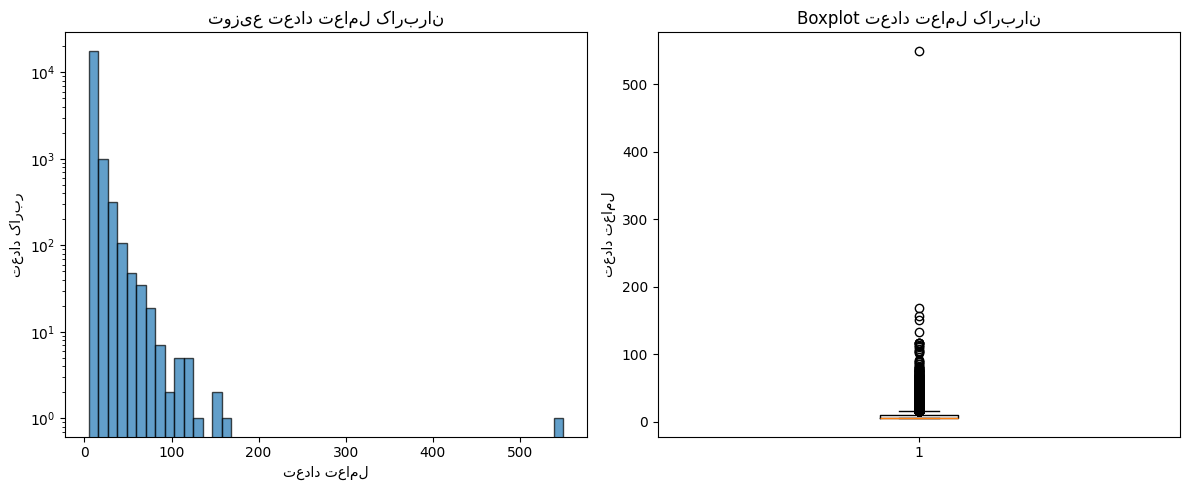

In [11]:

# فرض می‌کنم دیتافریم ratings رو قبلاً ساختی با ستون‌های user_id و item_id
user_counts = ratings.groupby("user_id").size()

# ========== آمار عددی ==========
print("=" * 40)
print("آمار تعداد تعامل هر کاربر:")
print("=" * 40)
print(f"تعداد کل کاربران     : {len(user_counts)}")
print(f"حداقل تعامل          : {user_counts.min()}")
print(f"حداکثر تعامل         : {user_counts.max()}")
print(f"میانگین تعامل        : {user_counts.mean():.2f}")
print(f"میانه (Median)       : {user_counts.median()}")
print(f"انحراف معیار         : {user_counts.std():.2f}")
print()
print("چارک‌ها:")
print(user_counts.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

# ========== نمودار ==========
plt.figure(figsize=(12, 5))

# نمودار ۱: هیستوگرام
plt.subplot(1, 2, 1)
plt.hist(user_counts, bins=50, edgecolor='black', alpha=0.7)
plt.title("توزیع تعداد تعامل کاربران")
plt.xlabel("تعداد تعامل")
plt.ylabel("تعداد کاربر")
plt.yscale("log")  # چون توزیع معمولاً خیلی نامتعادل هست

# نمودار ۲: Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(user_counts, vert=True, showfliers=True)
plt.title("Boxplot تعداد تعامل کاربران")
plt.ylabel("تعداد تعامل")

plt.tight_layout()
plt.show()

In [ ]:
print("\nتعداد کاربرانی که حداقل ۵ تعامل دارن:", (user_counts >= 5).sum())
print("تعداد کاربرانی که حداقل ۱۰ تعامل دارن:", (user_counts >= 10).sum())

UnboundLocalError: cannot access local variable 'x' where it is not associated with a value

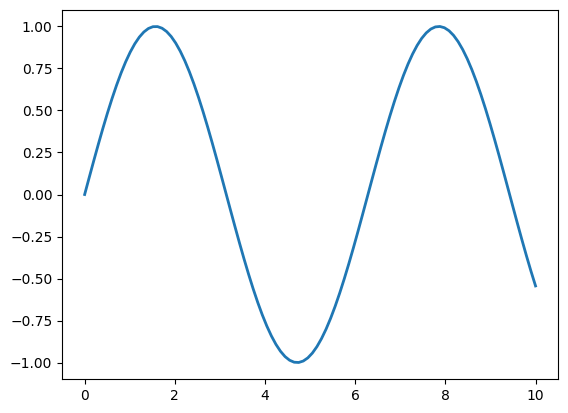

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time

# Sample data: Replace this with your own data
x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, ax = plt.subplots()
line, = ax.plot(x, y, lw=2)

# Function to add new data points
def add_data(num_points=10):
    new_x = np.linspace(x[-1], x[-1] + num_points * 0.1, num_points)
    new_y = np.sin(new_x)
    x = np.concatenate((x, new_x))
    y = np.concatenate((y, new_y))
    line.set_data(x, y)
    ax.set_xlim(min(x), max(x))
    ax.set_ylim(min(y), max(y))
    plt.draw()

# Main loop to update the plot
while True:
    add_data()
    time.sleep(1)  # Adjust the sleep time as needed for faster or slower updates

KeyboardInterrupt: 

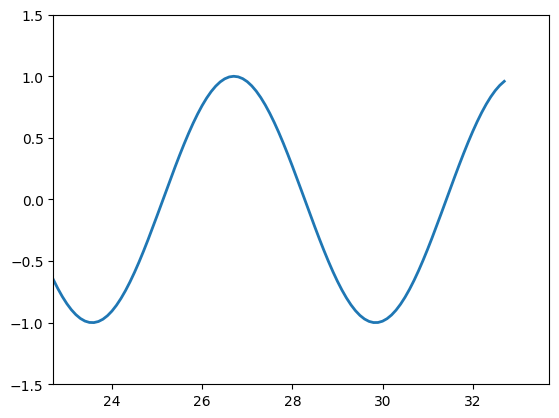

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import time

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.ion()  # Interactive mode

fig, ax = plt.subplots()
line, = ax.plot(x, y, lw=2)

ax.set_xlim(0, 20)
ax.set_ylim(-1.5, 1.5)

while True:
    # اضافه کردن یک نقطه جدید
    new_x = x[-1] + 0.1
    new_y = np.sin(new_x)

    x = np.append(x, new_x)
    y = np.append(y, new_y)

    line.set_data(x, y)

    # حرکت محور X
    ax.set_xlim(max(0, new_x - 10), new_x + 1)

    fig.canvas.draw()
    fig.canvas.flush_events()

    time.sleep(0.1)

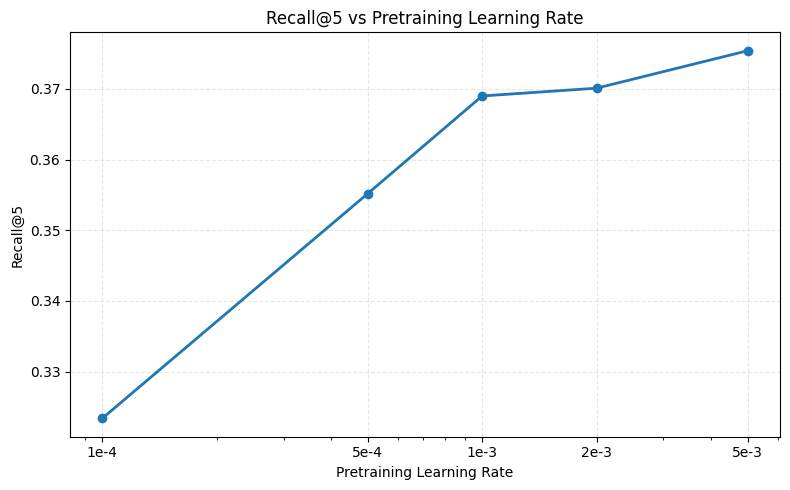

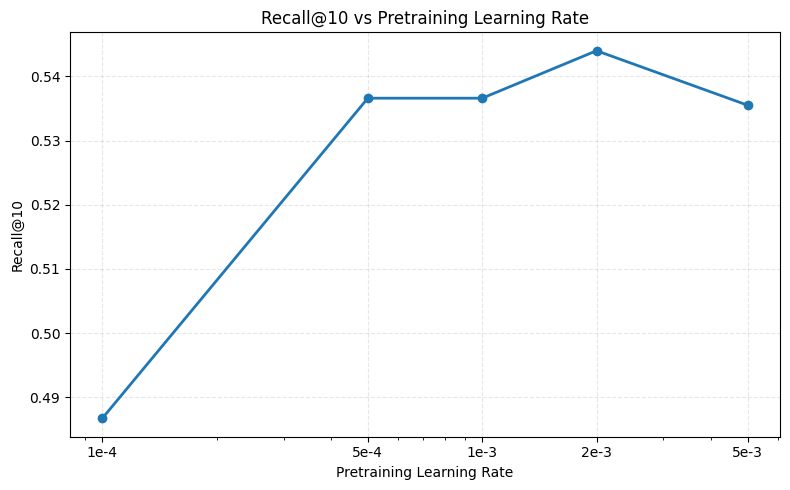

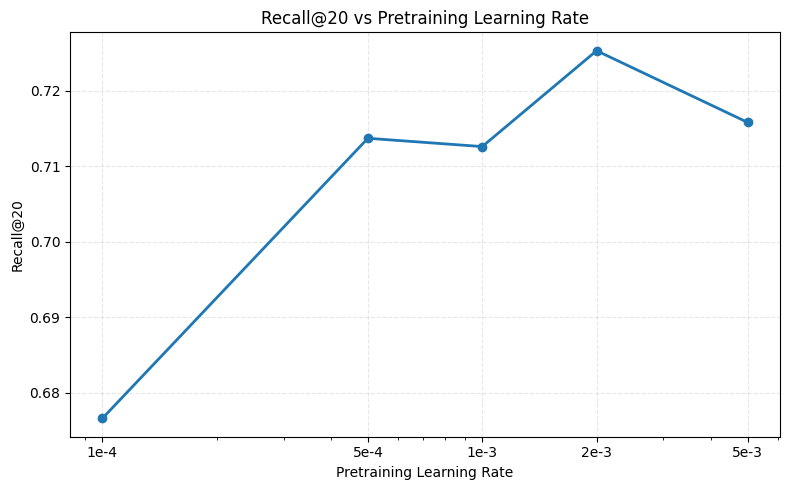

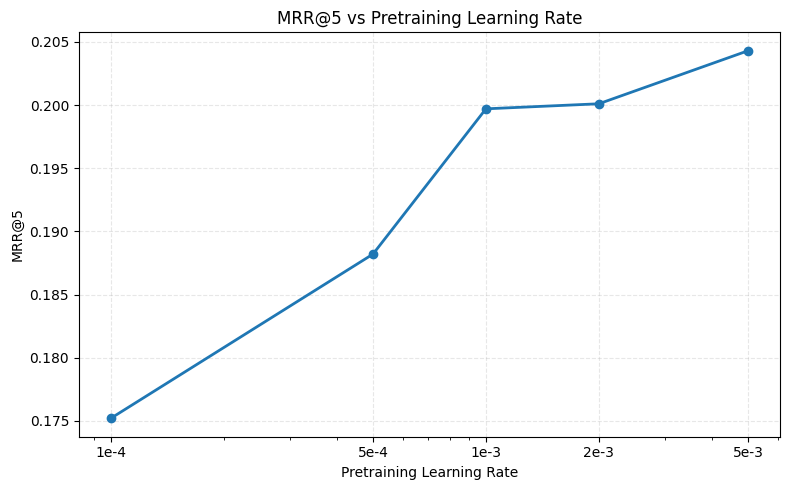

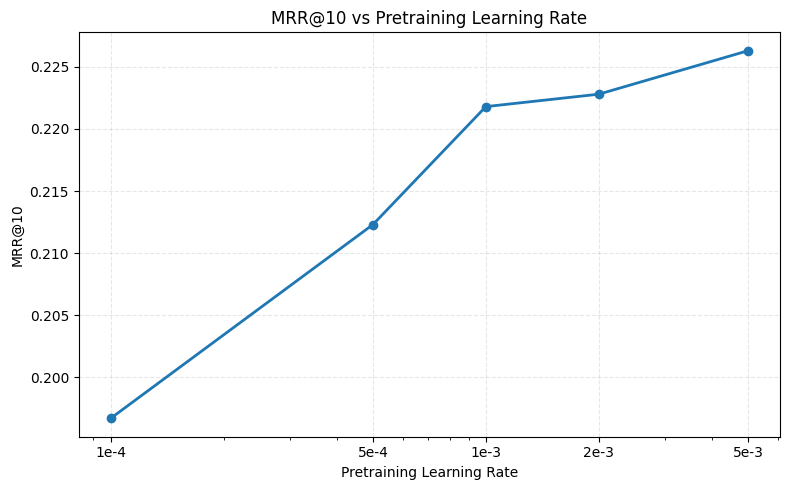

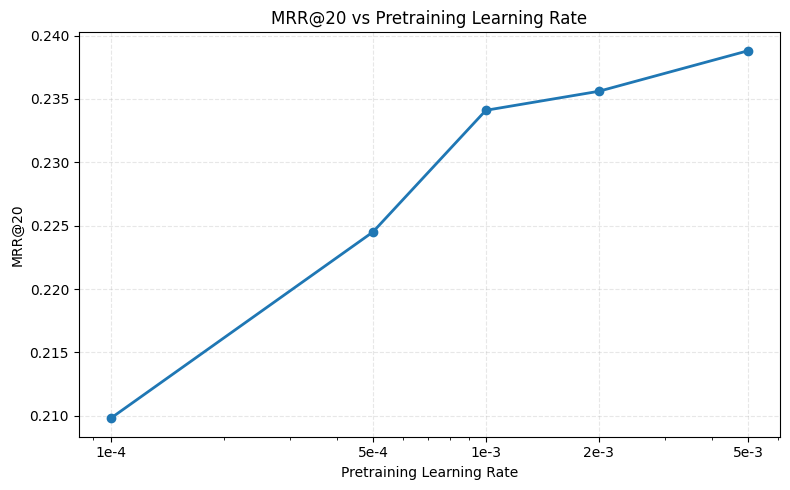

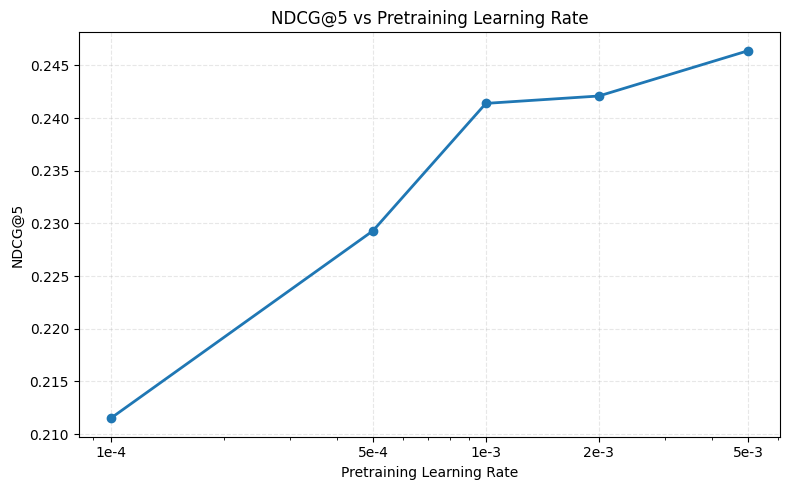

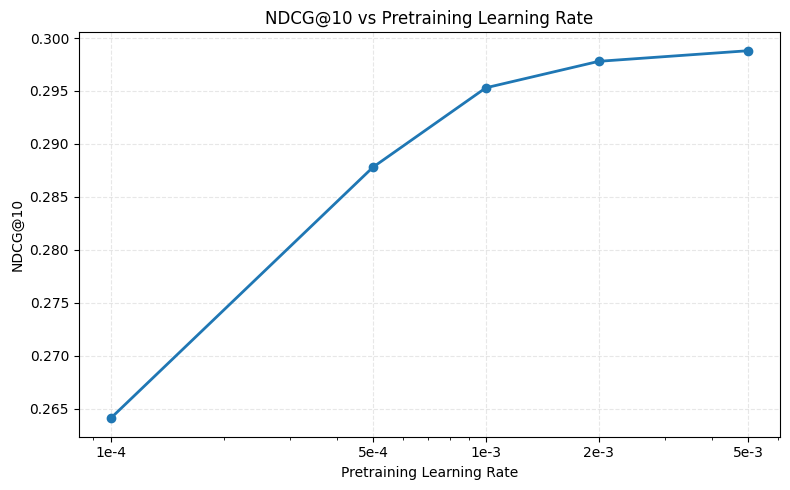

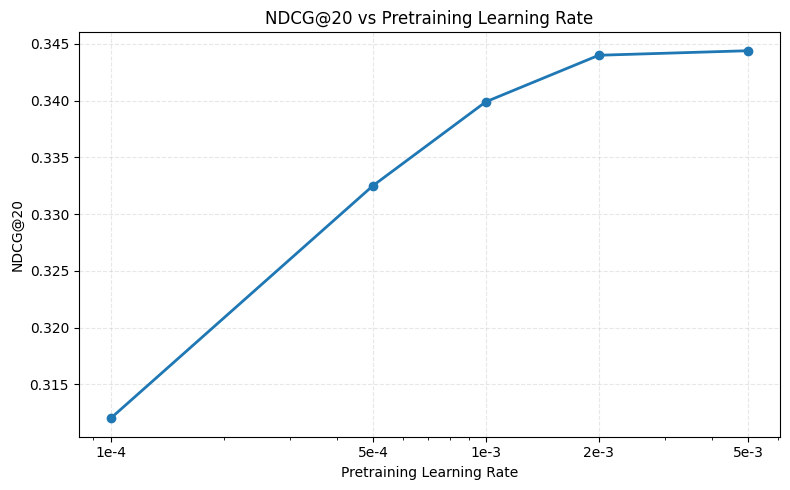

In [1]:
import matplotlib.pyplot as plt

learning_rates = [1e-4, 5e-4, 1e-3, 2e-3, 5e-3]

results = {
    "Recall@5":  [0.3234, 0.3552, 0.3690, 0.3701, 0.3754],
    "Recall@10": [0.4867, 0.5366, 0.5366, 0.5440, 0.5355],
    "Recall@20": [0.6766, 0.7137, 0.7126, 0.7253, 0.7158],

    "MRR@5":  [0.1752, 0.1882, 0.1997, 0.2001, 0.2043],
    "MRR@10": [0.1967, 0.2123, 0.2218, 0.2228, 0.2263],
    "MRR@20": [0.2098, 0.2245, 0.2341, 0.2356, 0.2388],

    "NDCG@5":  [0.2115, 0.2293, 0.2414, 0.2421, 0.2464],
    "NDCG@10": [0.2641, 0.2878, 0.2953, 0.2978, 0.2988],
    "NDCG@20": [0.3120, 0.3325, 0.3399, 0.3440, 0.3444]
}


for metric, values in results.items():

    plt.figure(figsize=(8, 5))

    plt.plot(
        learning_rates,
        values,
        marker="o",
        linewidth=2
    )

    plt.xscale("log")

    plt.xlabel("Pretraining Learning Rate")
    plt.ylabel(metric)

    plt.title(
        f"{metric} vs Pretraining Learning Rate"
    )

    plt.grid(
        True,
        linestyle="--",
        alpha=0.3
    )

    plt.xticks(
        learning_rates,
        ["1e-4", "5e-4", "1e-3", "2e-3", "5e-3"]
    )

    plt.tight_layout()

    plt.savefig(
        f"{metric.replace('@', '_at_')}_vs_learning_rate.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

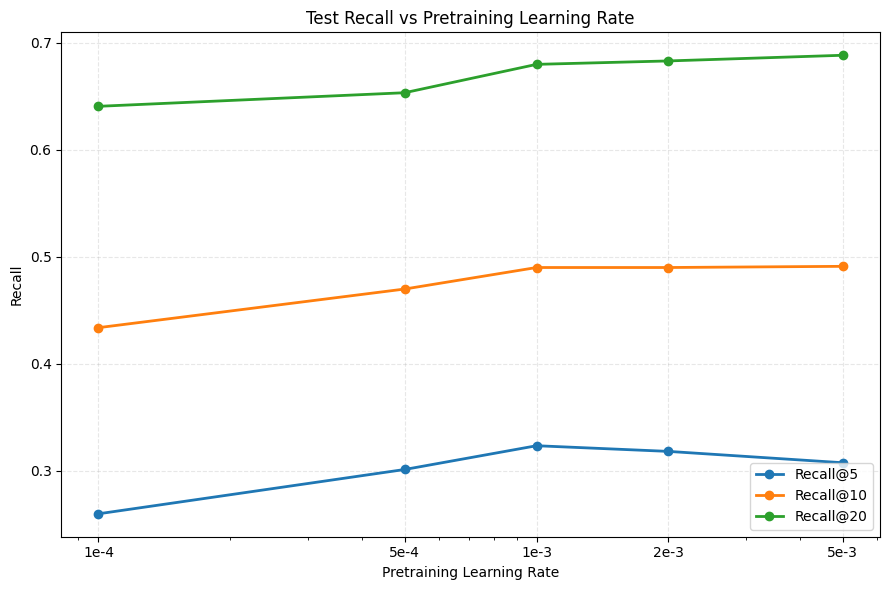

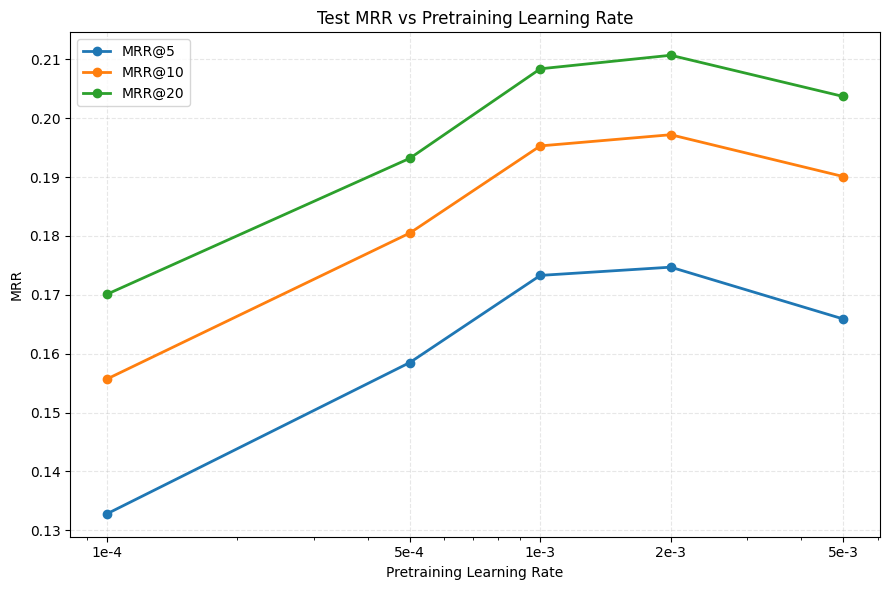

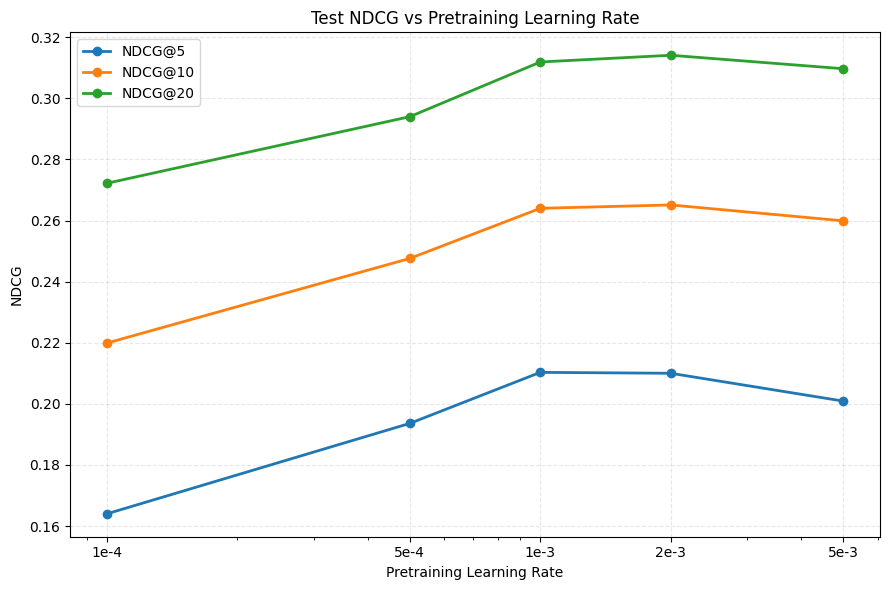

In [3]:
import matplotlib.pyplot as plt

# =========================
# Learning Rates
# =========================

learning_rates = [1e-4, 5e-4, 1e-3, 2e-3, 5e-3]

lr_labels = [
    "1e-4",
    "5e-4",
    "1e-3",
    "2e-3",
    "5e-3"
]


# =========================
# TEST RESULTS
# =========================

recall_5 =  [0.2598, 0.3012, 0.3234, 0.3181, 0.3075]
recall_10 = [0.4337, 0.4698, 0.4899, 0.4899, 0.4910]
recall_20 = [0.6405, 0.6532, 0.6797, 0.6829, 0.6882]

mrr_5 =  [0.1328, 0.1585, 0.1733, 0.1747, 0.1659]
mrr_10 = [0.1557, 0.1805, 0.1953, 0.1972, 0.1901]
mrr_20 = [0.1701, 0.1932, 0.2084, 0.2107, 0.2037]

ndcg_5 =  [0.1640, 0.1936, 0.2103, 0.2100, 0.2009]
ndcg_10 = [0.2199, 0.2476, 0.2640, 0.2651, 0.2599]
ndcg_20 = [0.2722, 0.2940, 0.3119, 0.3141, 0.3097]


# =========================================================
# 1. RECALL
# =========================================================

plt.figure(figsize=(9, 6))

plt.plot(
    learning_rates,
    recall_5,
    marker="o",
    linewidth=2,
    label="Recall@5"
)

plt.plot(
    learning_rates,
    recall_10,
    marker="o",
    linewidth=2,
    label="Recall@10"
)

plt.plot(
    learning_rates,
    recall_20,
    marker="o",
    linewidth=2,
    label="Recall@20"
)

plt.xscale("log")

plt.xticks(
    learning_rates,
    lr_labels
)

plt.xlabel("Pretraining Learning Rate")
plt.ylabel("Recall")

plt.title(
    "Test Recall vs Pretraining Learning Rate"
)

plt.legend()
plt.grid(
    True,
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "test_recall_learning_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 2. MRR
# =========================================================

plt.figure(figsize=(9, 6))

plt.plot(
    learning_rates,
    mrr_5,
    marker="o",
    linewidth=2,
    label="MRR@5"
)

plt.plot(
    learning_rates,
    mrr_10,
    marker="o",
    linewidth=2,
    label="MRR@10"
)

plt.plot(
    learning_rates,
    mrr_20,
    marker="o",
    linewidth=2,
    label="MRR@20"
)

plt.xscale("log")

plt.xticks(
    learning_rates,
    lr_labels
)

plt.xlabel("Pretraining Learning Rate")
plt.ylabel("MRR")

plt.title(
    "Test MRR vs Pretraining Learning Rate"
)

plt.legend()
plt.grid(
    True,
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "test_mrr_learning_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 3. NDCG
# =========================================================

plt.figure(figsize=(9, 6))

plt.plot(
    learning_rates,
    ndcg_5,
    marker="o",
    linewidth=2,
    label="NDCG@5"
)

plt.plot(
    learning_rates,
    ndcg_10,
    marker="o",
    linewidth=2,
    label="NDCG@10"
)

plt.plot(
    learning_rates,
    ndcg_20,
    marker="o",
    linewidth=2,
    label="NDCG@20"
)

plt.xscale("log")

plt.xticks(
    learning_rates,
    lr_labels
)

plt.xlabel("Pretraining Learning Rate")
plt.ylabel("NDCG")

plt.title(
    "Test NDCG vs Pretraining Learning Rate"
)

plt.legend()
plt.grid(
    True,
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "test_ndcg_learning_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()